# Tripartite Population Dynamics

### Imports

In [46]:
from src.model import deriv
from src.parameters import parameters
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import os

## First Analysis

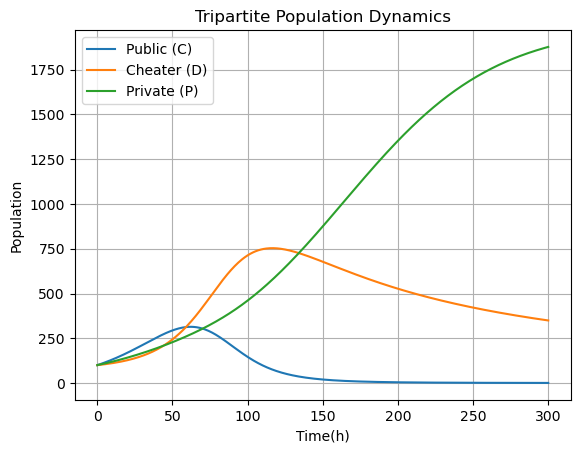

In [47]:
# Initial populations
y0 = [100.0, 100.0, 100.0]  # [C, D, P]
# Time points
t = np.linspace(0, 300, 500)

# Solve the system of ODEs
ret = odeint(deriv, y0, t, args=(
    parameters["nu"],
    parameters["beta"],
    parameters["alpha"],
    parameters["mu"],
    parameters["gamma"],
    parameters["eta"],
))

# Plot results
plt.figure()
plt.plot(t, ret[:, 0], label="Public (C)")
plt.plot(t, ret[:, 1], label="Cheater (D)")
plt.plot(t, ret[:, 2], label="Private (P)")
plt.xlabel("Time(h)")
plt.ylabel("Population")
plt.title("Tripartite Population Dynamics")
plt.legend()
plt.grid()
plt.savefig("output/figures/fig1.png", dpi=300)
plt.show()


# Simulating with different initial ratio


In [48]:
# Define initial conditions for different ratios
ratios = {
    "1:1:1": [100.0, 100.0, 100.0],  # C:D:P
    "1:5:1": [100.0, 500.0, 100.0],
    "1:10:1": [100.0, 1000.0, 100.0],
}

# Time points
t = np.linspace(0, 200, 500)

# Ensure output directory exists
os.makedirs("output/figures", exist_ok=True)

# Define colors for populations and line styles for ratios
colors = {"Public (C)": "green", "Cheater (D)": "black", "Private (P)": "blue"}
line_styles = {
    "1:1:1": "-",
    "1:5:1": "--",
    "1:10:1": ":",
}

def simulate_population(t, ratios, colors, line_styles, parameters, save_name_suffix):
    """
    Simulate and plot the dynamics for given time points.
    """
    for population, idx in zip(["Public (C)", "Cheater (D)", "Private (P)"], range(3)):
        plt.figure(figsize=(10, 6))
        for label, y0 in ratios.items():
            # Solve the system of ODEs
            ret = odeint(deriv, y0, t, args=(
                parameters["nu"],
                parameters["beta"],
                parameters["alpha"],
                parameters["mu"],
                parameters["gamma"],
                parameters["eta"],
            ))
            
            # Plot the specific population with the correct color and line style
            legend_label = f"Public:Cheater:Private - {label}"
            plt.plot(
                t, ret[:, idx],
                color=colors[population],  # Correct color applied here
                linestyle=line_styles[label],  # Line style for the ratio
                label=legend_label
            )

        # Customize the plot
        plt.xlabel("Time(h)", fontsize=14, fontweight="bold")
        plt.ylabel("Population(cell)", fontsize=14,fontweight="bold" )
        plt.title(f"{population} Population Dynamics", fontsize=16)
        plt.legend(title="Initial Ratios", fontsize=10)
        plt.grid()
        plt.tight_layout()

        # Save the figure with a suffix to distinguish results
        output_file = f"output/figures/{population.replace(' ', '_').lower()}_{save_name_suffix}.png"
        plt.savefig(output_file, dpi=300)
        plt.show()


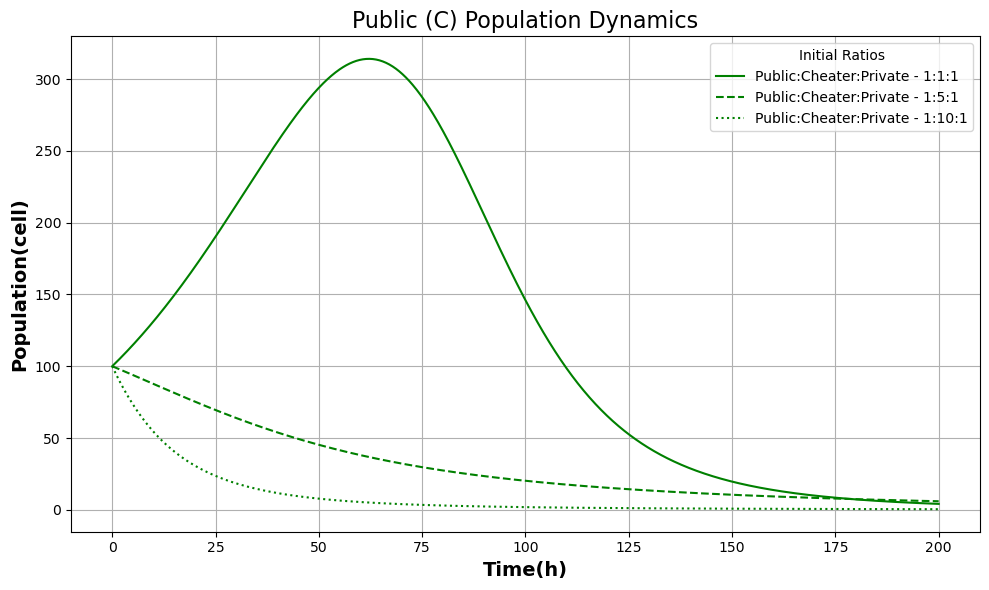

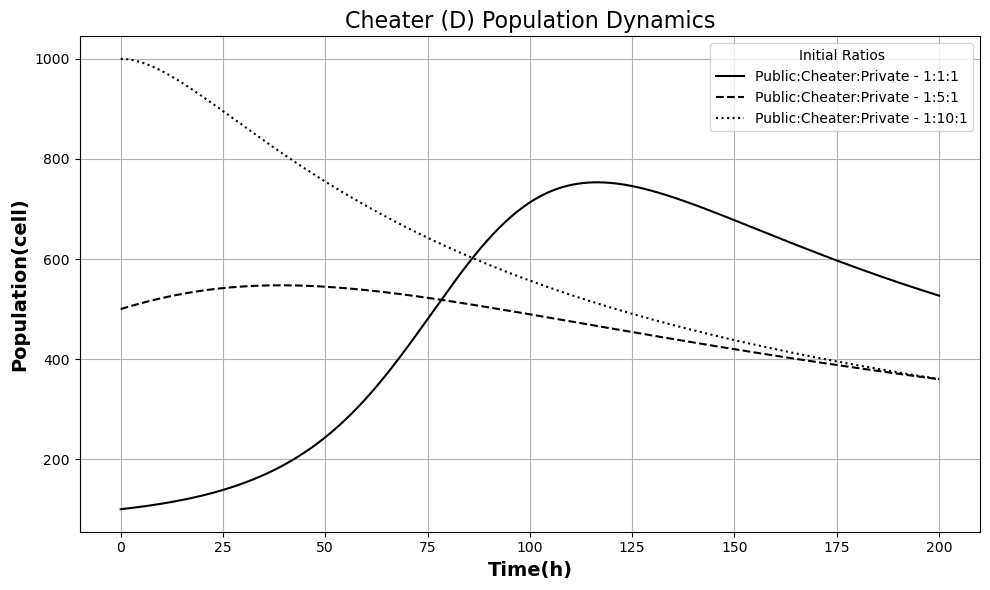

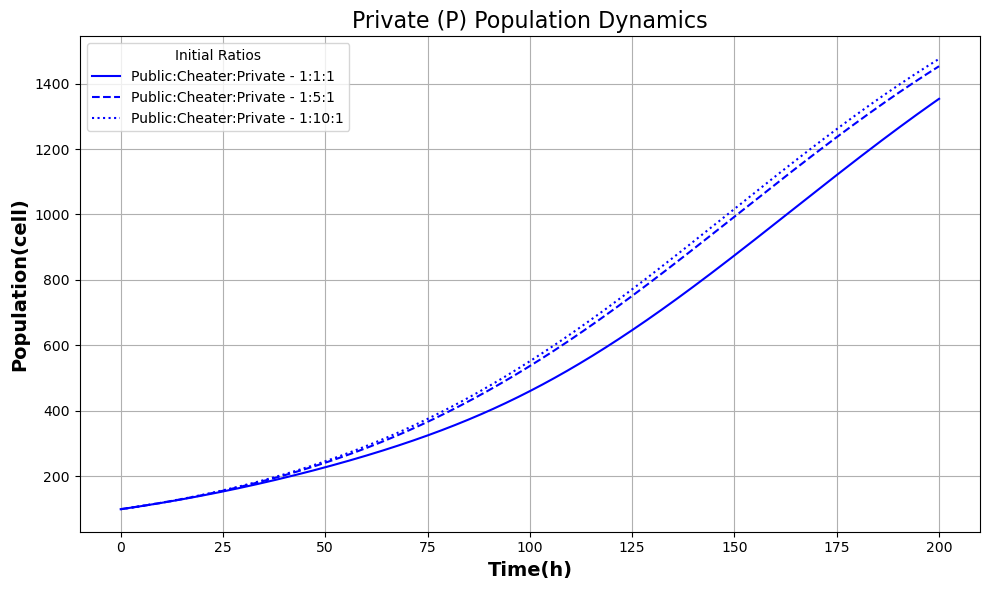

In [49]:
t_updated = np.linspace(0, 200, 1000)
simulate_population(t_updated, ratios, colors, line_styles, parameters, save_name_suffix="cheater_ra")

# longer time period

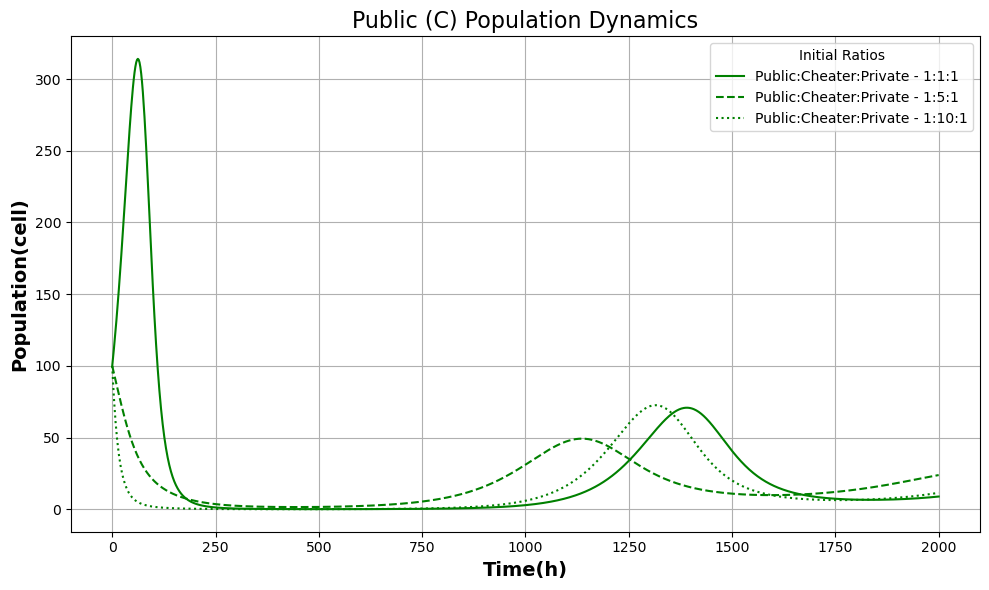

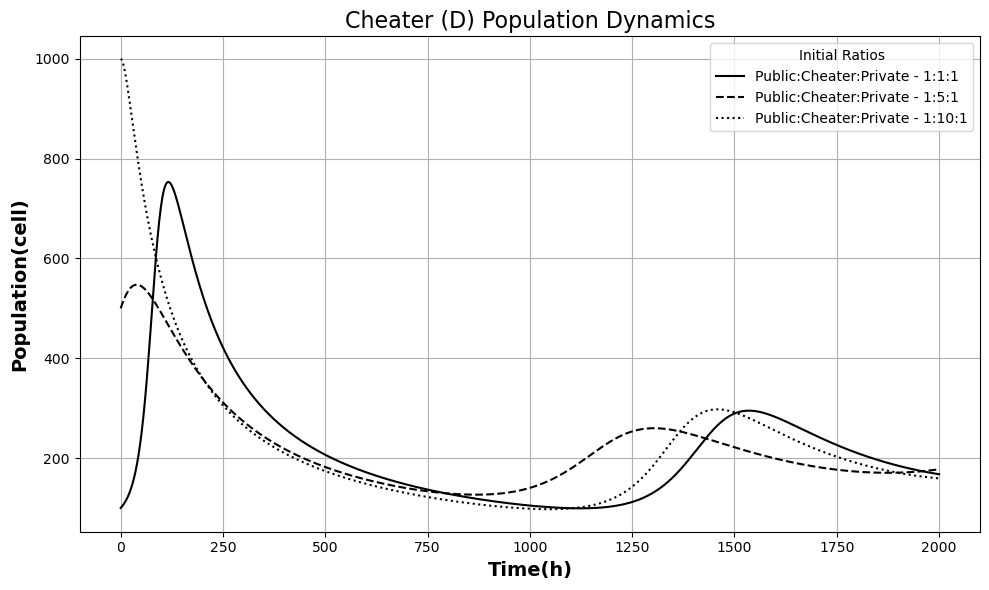

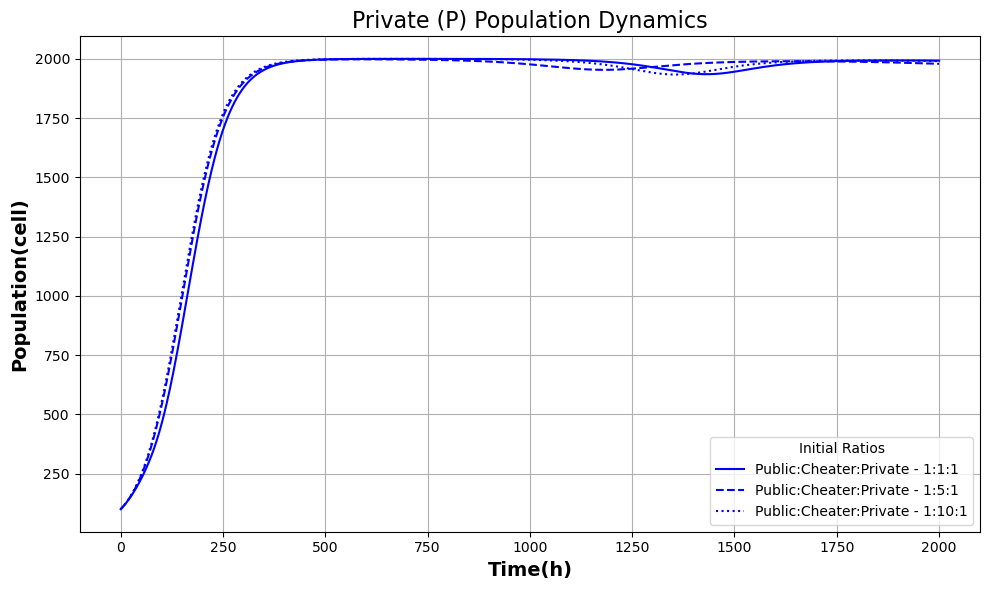

In [50]:
t_updated = np.linspace(0, 2000, 1000)
simulate_population(t_updated, ratios, colors, line_styles, parameters, save_name_suffix="updated_time")

# higher ratio of public population

In [51]:
# Updated ratios: Public (C) has initial ratio of 1, 5, and 10
ratios_updated = {
    "1:1:1": [100.0, 100.0, 100.0],  # C:D:P
    "5:1:1": [500.0, 100.0, 100.0],
    "10:1:1": [1000.0, 100.0, 100.0],
}

line_styles = {
    "1:1:1": "-",
    "5:1:1": "--",
    "10:1:1": ":",
}


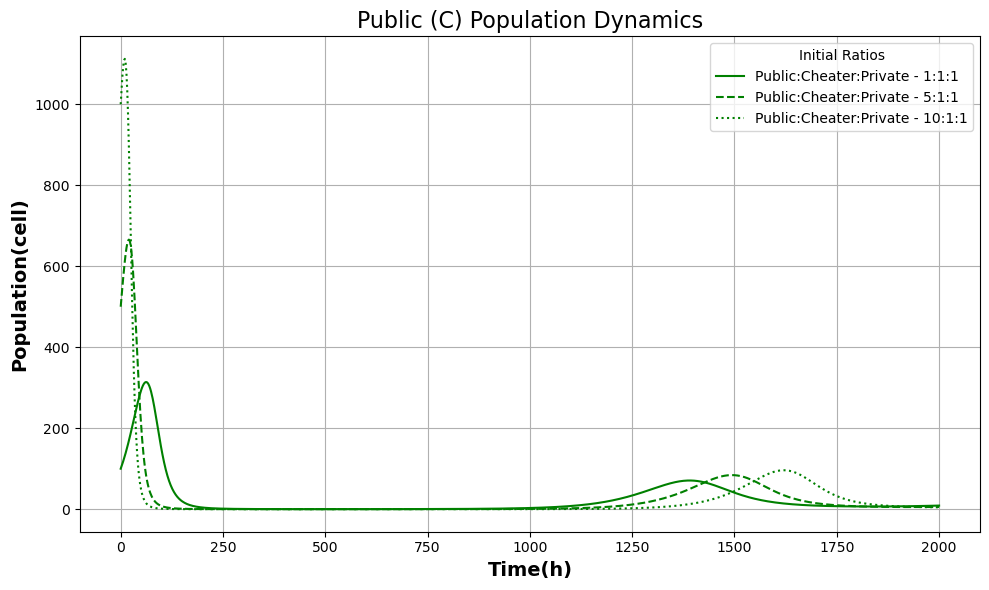

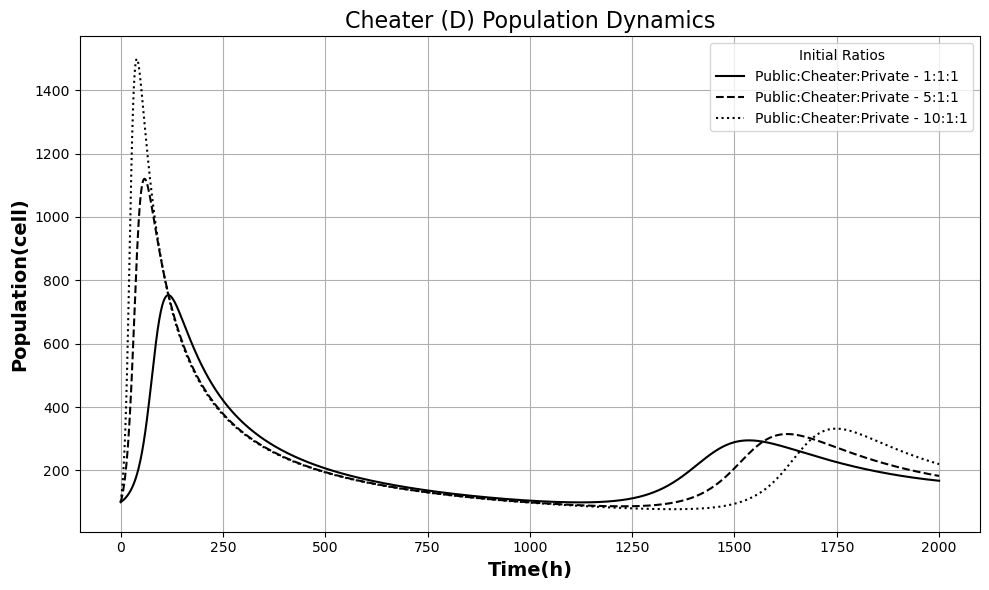

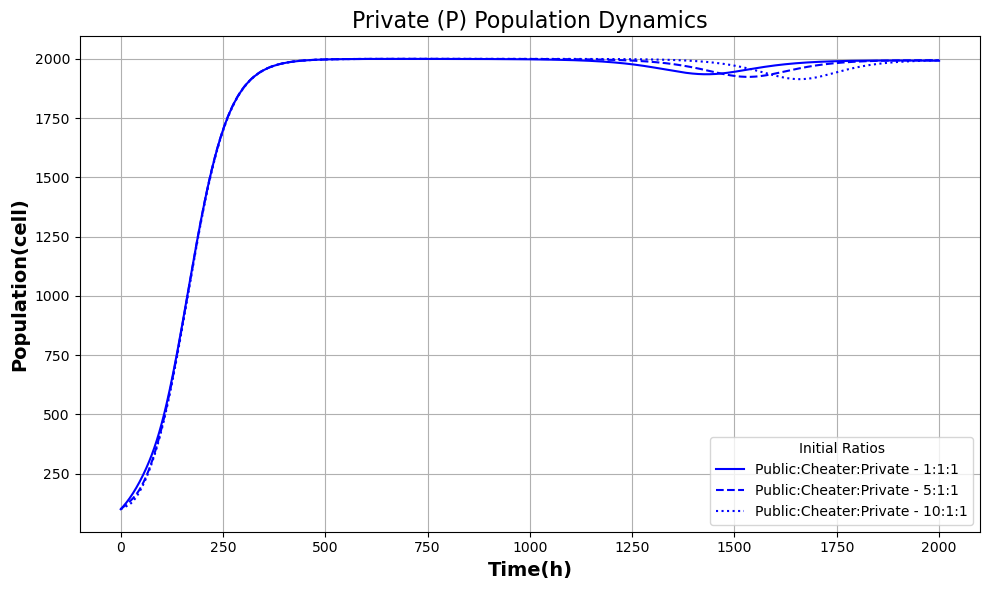

In [52]:
simulate_population(t_updated, ratios_updated, colors, line_styles, parameters, save_name_suffix="public_ratio")

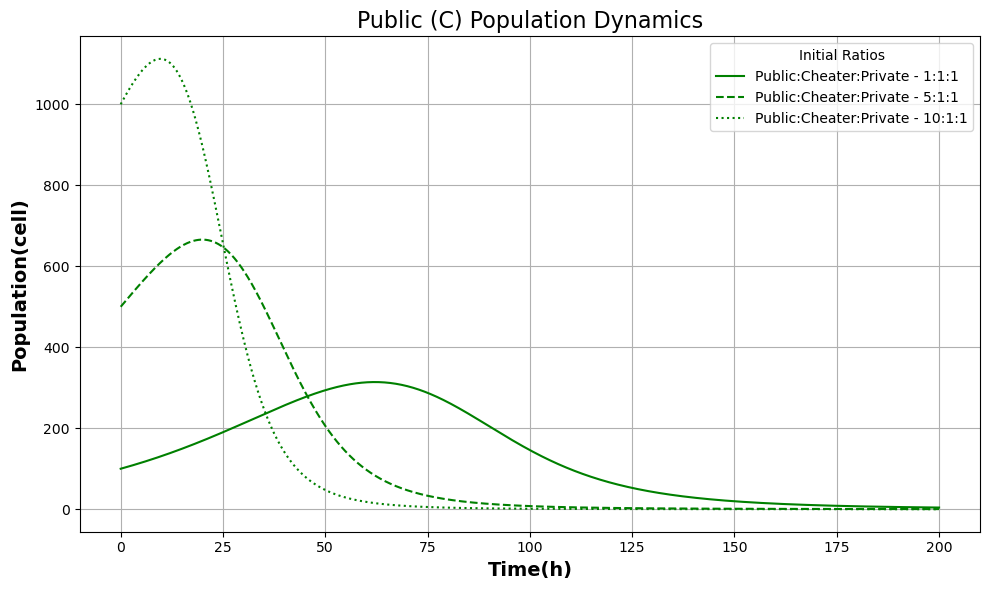

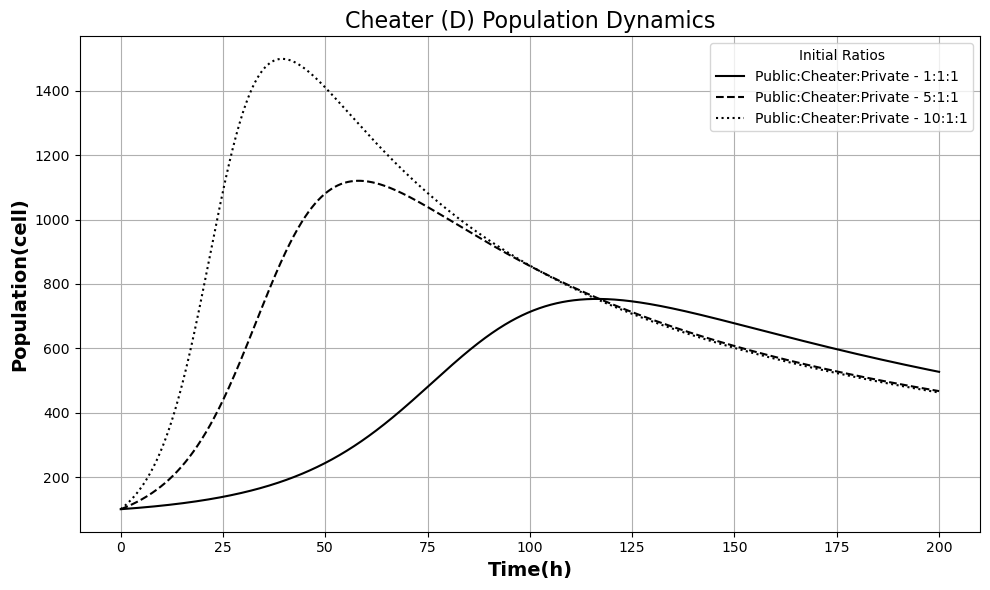

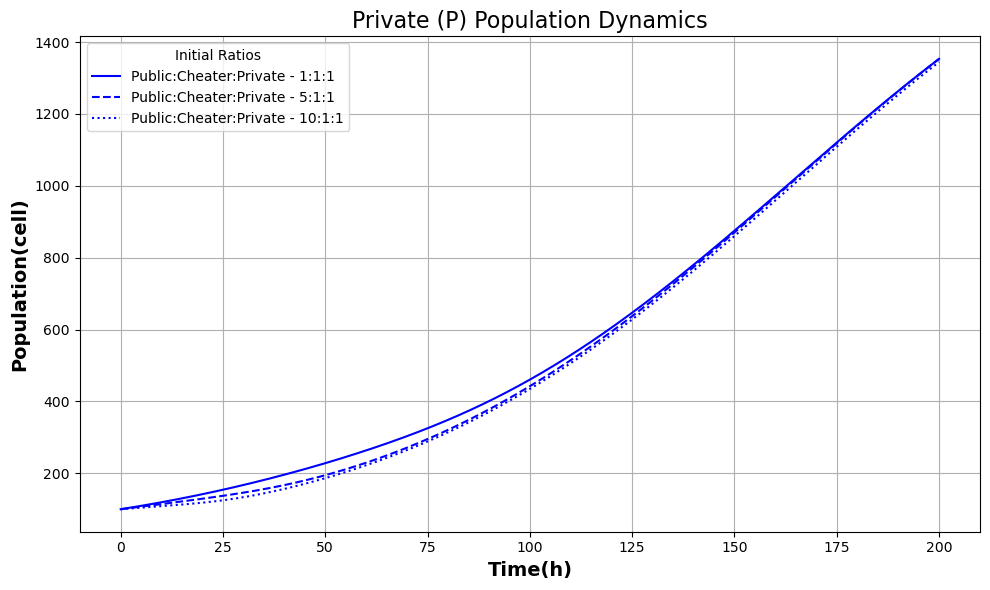

In [53]:
t_updated = np.linspace(0, 200, 1000)
simulate_population(t_updated, ratios_updated, colors, line_styles, parameters, save_name_suffix="public_ratio")

# Growth rate

In [85]:
# Different growth rates for Public (rc) and Private (rp)
growth_rates = {
    "low_growth": {"rc": 0.05, "rp": 0.08},
    "medium_growth": {"rc": 0.1, "rp": 0.15},
    "high_growth": {"rc": 0.2, "rp": 0.3},
}


In [86]:
def simulate_growth_rates(t, initial_condition, growth_rates, colors, line_styles, save_name_suffix):
    """
    Simulate dynamics for different growth rates with a fixed initial condition.
    """
    for growth_label, growth_rate in growth_rates.items():
        # Safely update the parameters with the current growth rates
        parameters["mu"] = {"rc": growth_rate["rc"], "rp": growth_rate["rp"]}

        plt.figure(figsize=(10, 6))
        for population, idx in zip(["Public (C)", "Cheater (D)", "Private (P)"], range(3)):
            ret = odeint(deriv, initial_condition, t, args=(
                parameters["nu"],
                parameters["beta"],
                parameters["alpha"],
                parameters["mu"],
                parameters["gamma"],
                parameters["eta"],
            ))
            legend_label = f"{population} - {growth_label.capitalize()}"
            plt.plot(
                t, ret[:, idx],
                color=colors[population],
                linestyle=line_styles[growth_label],
                label=legend_label
            )
        # Customize the plot
        plt.xlabel("Time", fontsize=14, fontweight="bold")
        plt.ylabel("Population", fontsize=12)
        plt.title(f"Population Dynamics ({growth_label.capitalize()})", fontsize=16)
        plt.legend(title="Growth Rate", fontsize=10)
        plt.grid()
        plt.tight_layout()

        # Save the figure with a suffix for growth rates
        output_file = f"output/figures/population_dynamics_{growth_label}_{save_name_suffix}.png"
        plt.savefig(output_file, dpi=300)
        plt.show()


# Stochastic dynamics in growth rate

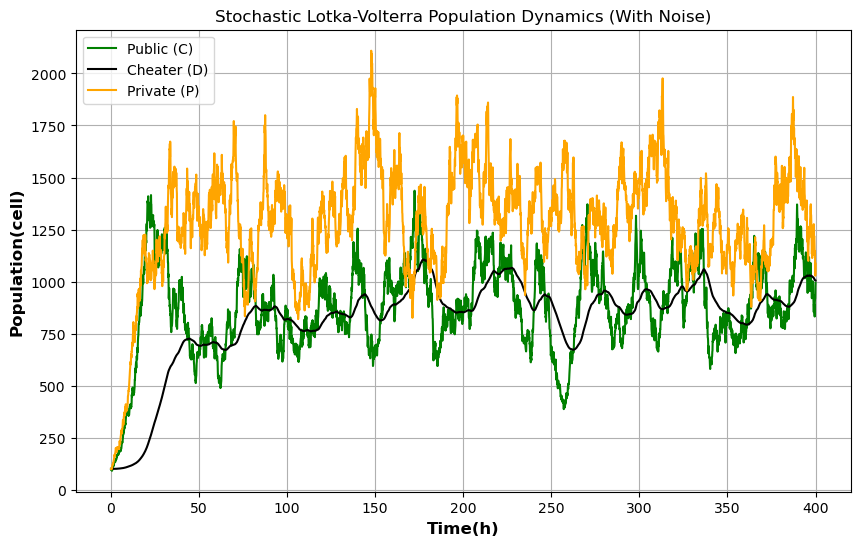

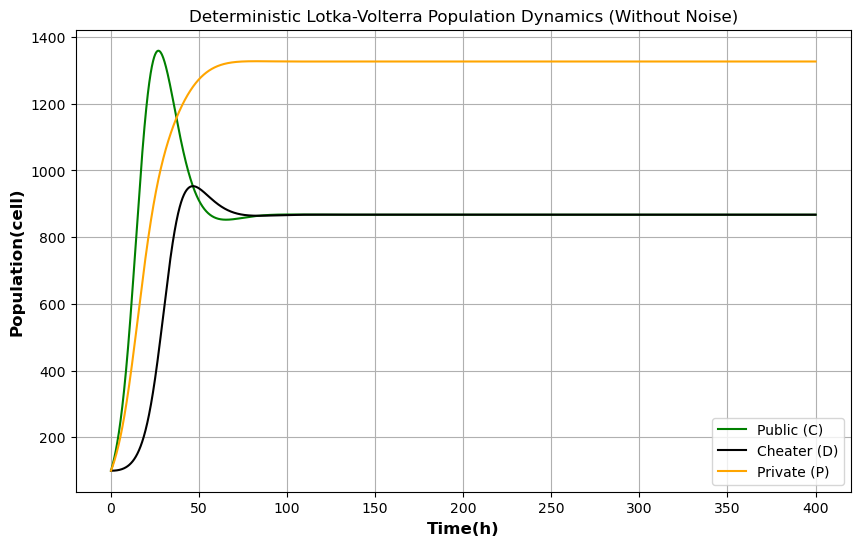

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from src.sto_parameters import parameters

# Simulation Function
def simulate_population(T, dt, C0, D0, P0, params, noise=True):
    # Simulation parameters
    n_steps = int(T / dt)
    time = np.linspace(0, T, n_steps)

    # Arrays to store population values
    C = np.zeros(n_steps)
    D = np.zeros(n_steps)
    P = np.zeros(n_steps)

    # Initial values
    C[0], D[0], P[0] = C0, D0, P0

    # Euler-Maruyama Simulation Loop
    for t in range(1, n_steps):
        dW_c = np.random.normal(0, np.sqrt(dt)) if noise else 0
        dW_p = np.random.normal(0, np.sqrt(dt)) if noise else 0
        
        # Stochastic differential equations
        dC = (params["r_c0"] * C[t-1] - params["alpha"] * C[t-1] * D[t-1] - params["beta"] * C[t-1] * P[t-1] - params["lambda_"] * C[t-1]**2) * dt \
             + params["sigma_c"] * C[t-1] * dW_c
        dD = (params["alpha"] * C[t-1] * D[t-1] - params["nu"] * D[t-1]**2) * dt
        dP = (params["r_p0"] * P[t-1] - params["beta"] * P[t-1] * C[t-1] - params["gamma"] * P[t-1]**2) * dt \
             + params["sigma_p"] * P[t-1] * dW_p

        # Update populations
        C[t] = max(C[t-1] + dC, 0)
        D[t] = max(D[t-1] + dD, 0)
        P[t] = max(P[t-1] + dP, 0)

    return time, C, D, P

# Run the simulations
T = 400    # Total time
dt = 0.1   # Time step
C0, D0, P0 = 100, 100, 100  # Initial conditions

# Simulate with noise
time, C_noise, D_noise, P_noise = simulate_population(T, dt, C0, D0, P0, parameters, noise=True)

# Plot with noise
plt.figure(figsize=(10, 6))
plt.plot(time, C_noise, label='Public (C)', color='green')
plt.plot(time, D_noise, label='Cheater (D)', color='black')
plt.plot(time, P_noise, label='Private (P)', color='orange')
plt.title('Stochastic Lotka-Volterra Population Dynamics (With Noise)')
plt.xlabel('Time(h)', fontsize=12, fontweight='bold')
plt.ylabel('Population(cell)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

# Simulate without noise
time, C_det, D_det, P_det = simulate_population(T, dt, C0, D0, P0, parameters, noise=False)

# Plot without noise
plt.figure(figsize=(10, 6))
plt.plot(time, C_det, label='Public (C)', color='green')
plt.plot(time, D_det, label='Cheater (D)', color='black')
plt.plot(time, P_det, label='Private (P)', color='orange')
plt.title('Deterministic Lotka-Volterra Population Dynamics (Without Noise)')
plt.xlabel('Time(h)', fontsize=12, fontweight='bold')
plt.ylabel('Population(cell)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()
